In [28]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd() / "src"))
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from src.data.download import download_xenium_dataset

url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
output_dir = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw"

download_xenium_dataset(url, output_dir)

'src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw'

In [29]:
from src.scripts.preprocessing.loaders import load_cells_table, load_expression_matrix

cells_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw/cells.parquet"
expr_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/xenium_raw/cell_feature_matrix.h5"

cells_df = load_cells_table(cells_path)
adata = load_expression_matrix(expr_path, False)

In [30]:
from src.scripts.preprocessing.normalization import pydeseq2_normalize_global
from src.utils.logging_utils import logger# Apply PyDESeq2 normalization
adata_normalized, size_factors = pydeseq2_normalize_global(
    adata, 
    min_genes=20, 
    apply_log1p=True
)

PyDESeq2 returned all NaN size factors, falling back to custom implementation
Global median is 0, setting all size factors to 1.0


Original: 62268 cells → Filtered: 56962 cells


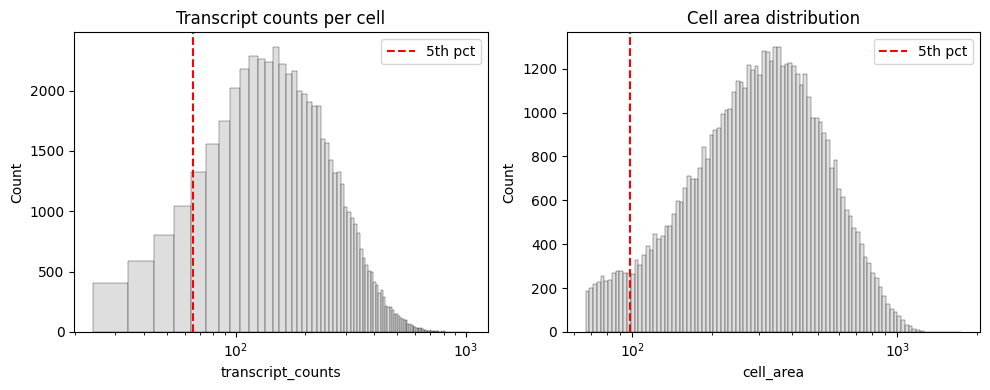

In [4]:
from src.scripts.preprocessing.qc import filter_cells, plot_qc_distributions

filtered_cells_df = filter_cells(cells_df, transcript_q=0.05, area_q=0.05)

print(f"Original: {cells_df.shape[0]} cells → Filtered: {filtered_cells_df.shape[0]} cells")

plot_qc_distributions(filtered_cells_df, transcript_q=0.05, area_q=0.05)

In [5]:
from src.scripts.preprocessing.plaque_distance import (
    compute_cell_to_plaque_distance,
    load_plaque_polygons,
)

# Paths

plaques_path = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/plaque_polygons.csv"
plaques_gdf = load_plaque_polygons(plaques_path)

# Compute per-cell distances
cells_with_dist = compute_cell_to_plaque_distance(filtered_cells_df, plaques_gdf)

cells_with_dist.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,distance_to_plaque
0,b'aaabiggh-1',831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,35.775568
1,b'aaacfoel-1',821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,37.307845
2,b'aaaeefil-1',831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,23.175138
3,b'aaaehidd-1',853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,7.126988
4,b'aaagcbkg-1',821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,26.299783


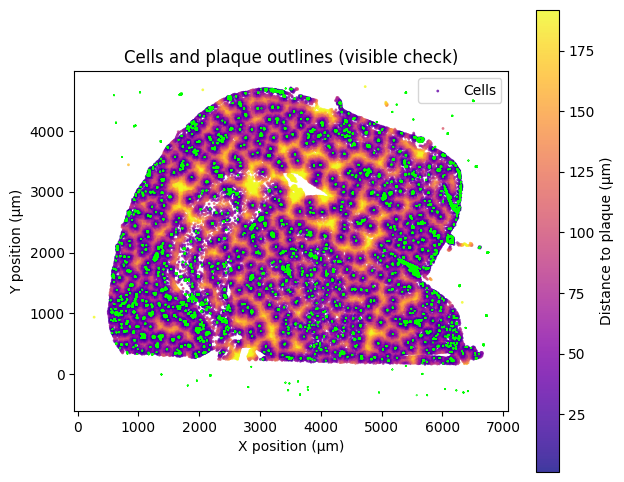

In [6]:
from src.scripts.preprocessing.plaque_distance import plot_cell_to_plaque_map_visible

plot_cell_to_plaque_map_visible(cells_with_dist, plaques_gdf)

In [7]:
from src.scripts.preprocessing.loaders import merge_expression_with_cells

combined_df = merge_expression_with_cells(cells_with_dist, adata)
combined_df.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Unc13c,Vat1l,Vcan,Vim,Vip,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,0,4.0,0,0,0,3.0,0,0,0,1.0
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,0,0,0,1.0,0,2.0,0,0,0,1.0
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,1.0,0,0,0,0,0,1.0,0,0,2.0
3,aaaehidd-1,853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,...,0,8.0,0,1.0,0,4.0,4.0,0,0,2.0
4,aaagcbkg-1,821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,...,0,2.0,0,3.0,0,0,0,0,0,2.0


In [9]:
from src.scripts.preprocessing.loaders import merge_expression_with_cells

combined_df_2 = merge_expression_with_cells(cells_with_dist, adata_normalized)
combined_df_2.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Unc13c,Vat1l,Vcan,Vim,Vip,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,0.000000,1.609438,0.0,0.000000,0.0,1.386294,0.000000,0.0,0.0,0.693147
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,0.000000,0.000000,0.0,0.693147,0.0,1.098612,0.000000,0.0,0.0,0.693147
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,0.693147,0.000000,0.0,0.000000,0.0,0.000000,0.693147,0.0,0.0,1.098612
3,aaaehidd-1,853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,...,0.000000,2.197225,0.0,0.693147,0.0,1.609438,1.609438,0.0,0.0,1.098612
4,aaagcbkg-1,821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,...,0.000000,1.098612,0.0,1.386294,0.0,0.000000,0.000000,0.0,0.0,1.098612


In [ ]:
combined_df_2.to_csv("src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/combined.csv", index=False)

NameError: name 'combined_df_2' is not defined

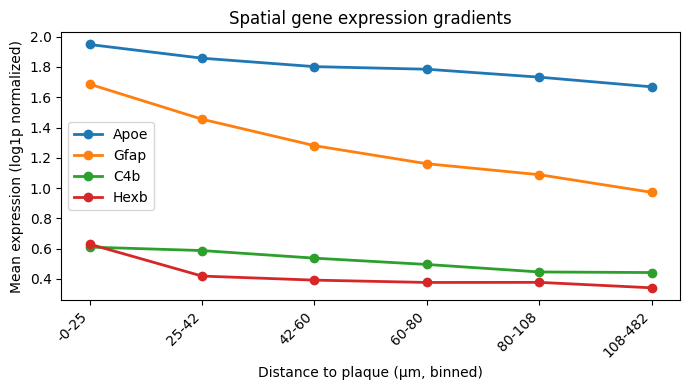

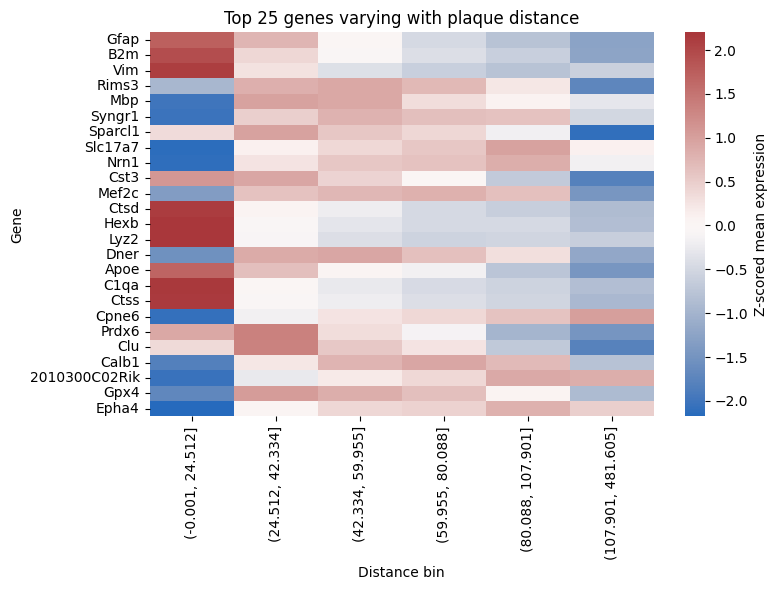

In [14]:
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    plot_gene_trends,
    plot_mean_heatmap,
)

combined_binned = assign_distance_bins(combined_df, n_bins=6)

gene_cols = [
    c
    for c in combined_df.columns
    if c
    not in [
        "cell_id",
        "x_centroid",
        "y_centroid",
        "cell_area",
        "transcript_counts",
        "distance_to_plaque",
        "distance_bin",
    ]
]

mean_expr = mean_expression_by_bin(combined_binned, gene_cols)

# Plot trends for known PIG genes
plot_gene_trends(mean_expr, ["Apoe", "Gfap", "C4b", "Hexb"])

# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25)

,gene,spearman_r,spearman_p,slope,fdr_pval
4,2010300C02Rik,0.091484,4.053895e-106,0.001473,4.065478e-105
255,Ppp1r1b,0.088386,3.729267e-99,0.001027,3.537764e-98
79,Cpne6,0.085885,1.037302e-93,0.001560,9.581395e-93
308,Spag16,0.081880,2.551863e-85,0.000583,2.132628e-84
191,Mdga1,0.079716,5.925333e-81,0.000494,4.521287e-80
26,Bcl11b,0.075774,2.642344e-73,0.000661,1.749930e-72
228,Orai2,0.074905,1.137453e-71,0.000642,7.259021e-71
195,Meis2,0.074181,2.520262e-70,0.001015,1.579664e-69
290,Sipa1l3,0.074173,2.613347e-70,0.000875,1.609272e-69
284,Sema3e,0.072708,1.262733e-67,0.000684,7.148699e-67


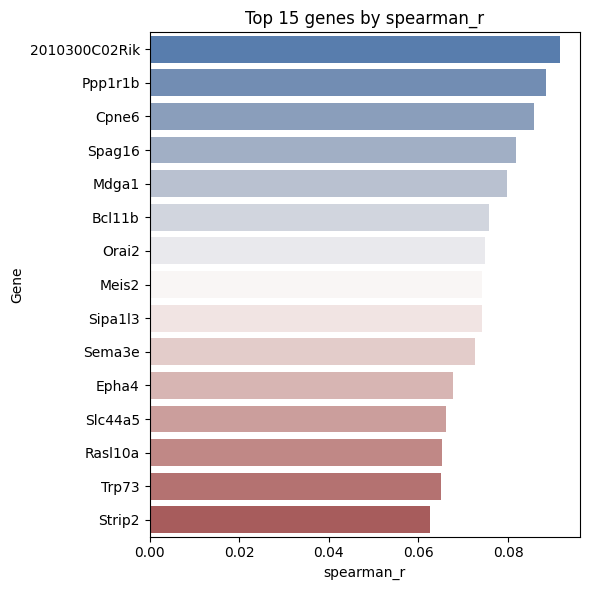

In [16]:
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    plot_top_spatial_genes,
)

gene_cols = [
    g
    for g in combined_df.columns
    if g
    not in [
        "cell_id",
        "x_centroid",
        "y_centroid",
        "cell_area",
        "distance_to_plaque",
        "transcript_counts",
        "nucleus_area",
    ]
]

stats_df = compute_gene_spatial_stats(combined_df, gene_cols)

# filter for significant positive correlations
sig_pos = stats_df.query("fdr_pval < 0.05 and spearman_r > 0").head(15)
display(sig_pos)

# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r")

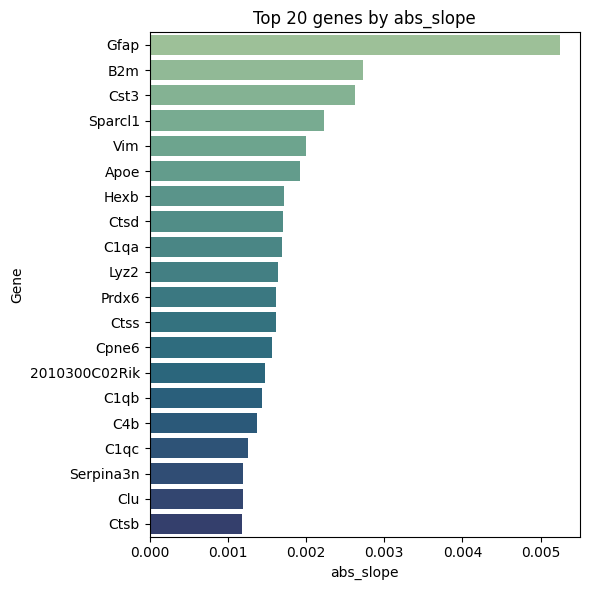

In [17]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
)

In [31]:
from scipy.stats import skew, kurtosis
import pandas as pd
import numpy as np
from src.scripts.preprocessing.partition import split_meta_vs_genes, DEFAULT_META_COLS

print("\n" + "="*88)
print("SECTION 1: COLUMN PARTITION — meta vs. gene features")
print("="*88)

df = pd.read_csv("src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/combined.csv")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in num_cols if c not in DEFAULT_META_COLS]

meta, genes, info = split_meta_vs_genes(df, meta_cols=DEFAULT_META_COLS)
print(f"Numeric columns: {info['n_numeric']}")
print(f"Gene feature columns: {info['n_genes']}")
print("Sample gene columns:", list(genes.columns[:10]))


SECTION 1: COLUMN PARTITION — meta vs. gene features
Numeric columns: 357
Gene feature columns: 348
Sample gene columns: ['distance_to_plaque', '2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2']


In [3]:
print("\n" + "="*88)
print("SECTION 2: QC METRICS & FILTERING — remove cells with weird expression")
print("="*88)

from src.scripts.preprocessing.partition import filter_cells_iqr
df_clean, mask, bounds, nums, desc = filter_cells_iqr(
    df,
    gene_cols=gene_cols,
    area_col="cell_area",
    nucleus_col="nucleus_area",
    iqr_mult=3.0,
)

print(f"Cells kept: {nums['kept']:,} / {nums['total']:,}  |  Removed: {nums['removed']:,}")
print(
    f"n_counts kept in [{bounds.lo_counts:,.2f}, {bounds.hi_counts:,.2f}] | "
    f"n_genes kept in [{bounds.lo_genes:,.2f}, {bounds.hi_genes:,.2f}]"
)

display(desc)



SECTION 2: QC METRICS & FILTERING — remove cells with weird expression
Cells kept: 56,956 / 56,962  |  Removed: 6
n_counts kept in [1.00, 398.76] | n_genes kept in [1.00, 199.00]


,count,mean,std,min,25%,50%,75%,max
n_counts,56956.0,145.760360,53.147477,12.951401,107.151444,141.835851,180.039729,394.809246
n_genes,56956.0,69.934054,24.763698,9.000000,51.000000,69.000000,88.000000,176.000000
cell_area,56956.0,338.115898,187.400769,66.650625,196.655469,303.133906,442.305469,1741.360469
nucleus_area,56956.0,41.066802,24.354908,3.702812,23.255469,35.583125,55.361563,214.672812


In [4]:
print("\n" + "="*88)
print("SECTION 3: DISTRIBUTION SUMMARY — per-gene statistics (cleaned cells)")
print("="*88)

from src.scripts.preprocessing.partition import summarize_genes

g = df_clean[gene_cols]
summary = summarize_genes(df_clean[gene_cols])

print(f"Genes summarized: {len(summary):,}")
display(summary.head(10))


SECTION 3: DISTRIBUTION SUMMARY — per-gene statistics (cleaned cells)
Genes summarized: 348


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,0.563051,0.757771,0.0,0.0,1.111670,0.145302,0.428892
Abca7,0.129029,0.307879,0.0,0.0,2.271217,4.252772,0.160492
Acsbg1,0.391331,0.534721,0.0,0.0,1.107750,0.281342,0.399870
Acta2,0.070962,0.271227,0.0,0.0,4.878191,29.421270,0.079289
Acvrl1,0.058056,0.226408,0.0,0.0,4.164628,18.033881,0.067947
Adamts2,0.074590,0.251563,0.0,0.0,3.565095,13.077819,0.088893
Adamtsl1,0.055868,0.206416,0.0,0.0,3.768697,14.170979,0.072301
Adgrl4,0.090465,0.300027,0.0,0.0,3.571685,12.972427,0.095021
Aldh1a2,0.042128,0.230651,0.0,0.0,6.349052,44.628661,0.038749


In [6]:
print("\n" + "="*88)
print("SECTION 4: PIG PANEL — presence check and z-scored matrix")
print("="*88)

from src.scripts.preprocessing.partition import compute_pigs_zscores

pigs_z, info = compute_pigs_zscores(df_clean, gene_cols)

print(f"PIGs present: {len(info['present'])} | Missing: {info['missing']}")
print("Z-scored PIG matrix shape:", pigs_z.shape)
display(pigs_z.head())


SECTION 4: PIG PANEL — presence check and z-scored matrix
PIGs present: 16 | Missing: []
Z-scored PIG matrix shape: (56956, 16)


,Hexb,Cst3,Cd63,C4b,Ctsd,B2m,H2-K1,Apoe,Gfap,Nrep,Serpina3n,Cd74,Cxcl10,Vim,S100a6,Ifit3
0,-0.696316,1.027807,0.137416,1.318810,2.212587,0.567741,0.727942,0.177437,0.899947,3.325251,-0.539352,-0.307242,-0.105804,-0.623619,-0.531954,1.259437
1,0.445735,0.847893,0.797972,-0.790813,0.355950,1.352630,0.727942,0.608359,1.002626,2.869321,2.293712,-0.307242,-0.105804,0.558639,-0.531954,-0.488672
2,0.445735,0.692933,0.797972,0.263998,-0.029337,-0.055261,1.569276,1.176200,0.504800,-0.660905,1.705798,-0.307242,-0.105804,-0.623619,-0.531954,1.259437
3,1.955445,1.220625,1.927199,1.658383,2.698619,2.417658,-0.710328,1.176200,1.095511,3.847157,0.877180,1.724953,-0.105804,0.558639,-0.531954,1.259437
4,0.445735,1.068903,-0.991811,-0.790813,0.898981,-1.120289,0.727942,0.481066,1.970603,2.869321,-0.539352,-0.307242,-0.105804,1.740896,2.172379,-0.488672


In [ ]:
print("\n" + "="*88)
print("SECTION 5: DISTRIBUTIONS — histogram + KDE for selected genes (cleaned cells)")
print("="*88)
from src.scripts.preprocessing.partition import plot_gene_distributions

plot_gene_distributions(
    df_clean,
    genes=info["present"],   # list of genes you got from compute_pigs_zscores
)


SECTION 5: DISTRIBUTIONS — histogram + KDE for selected genes (cleaned cells)


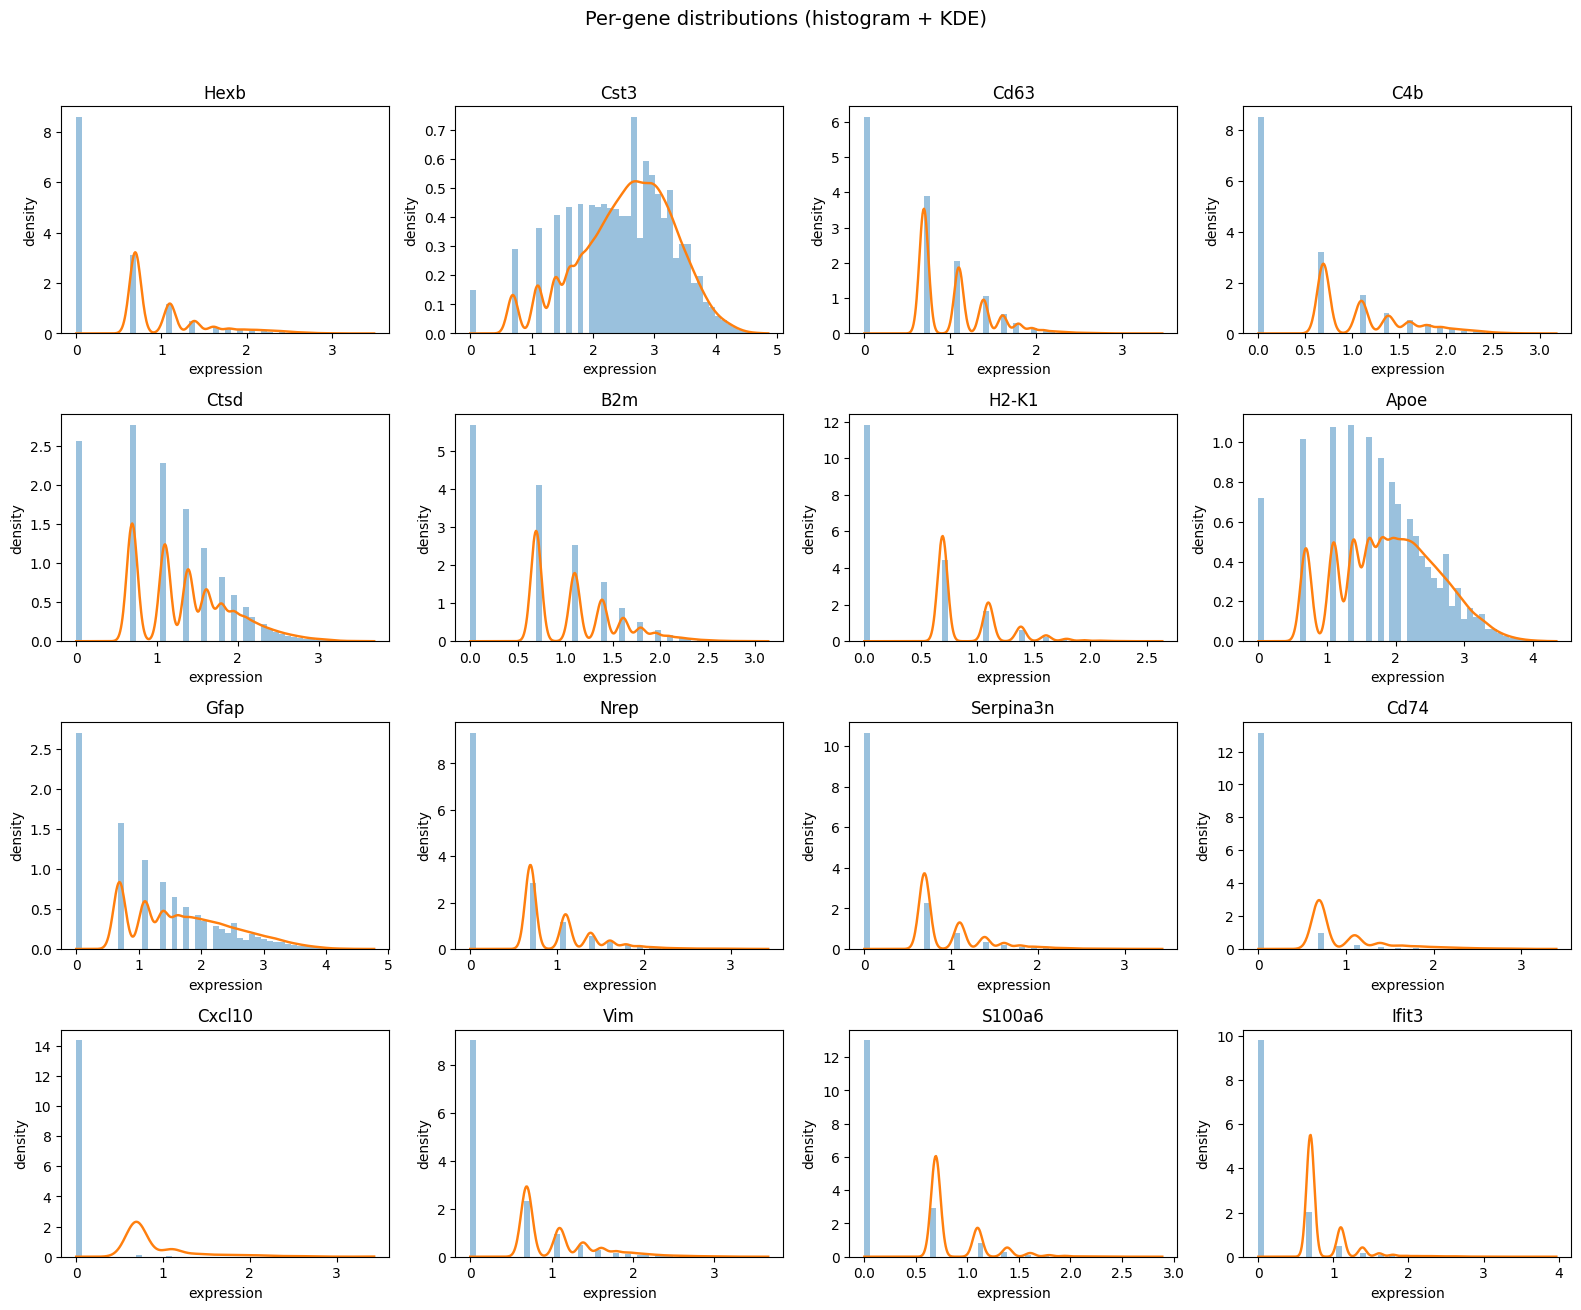

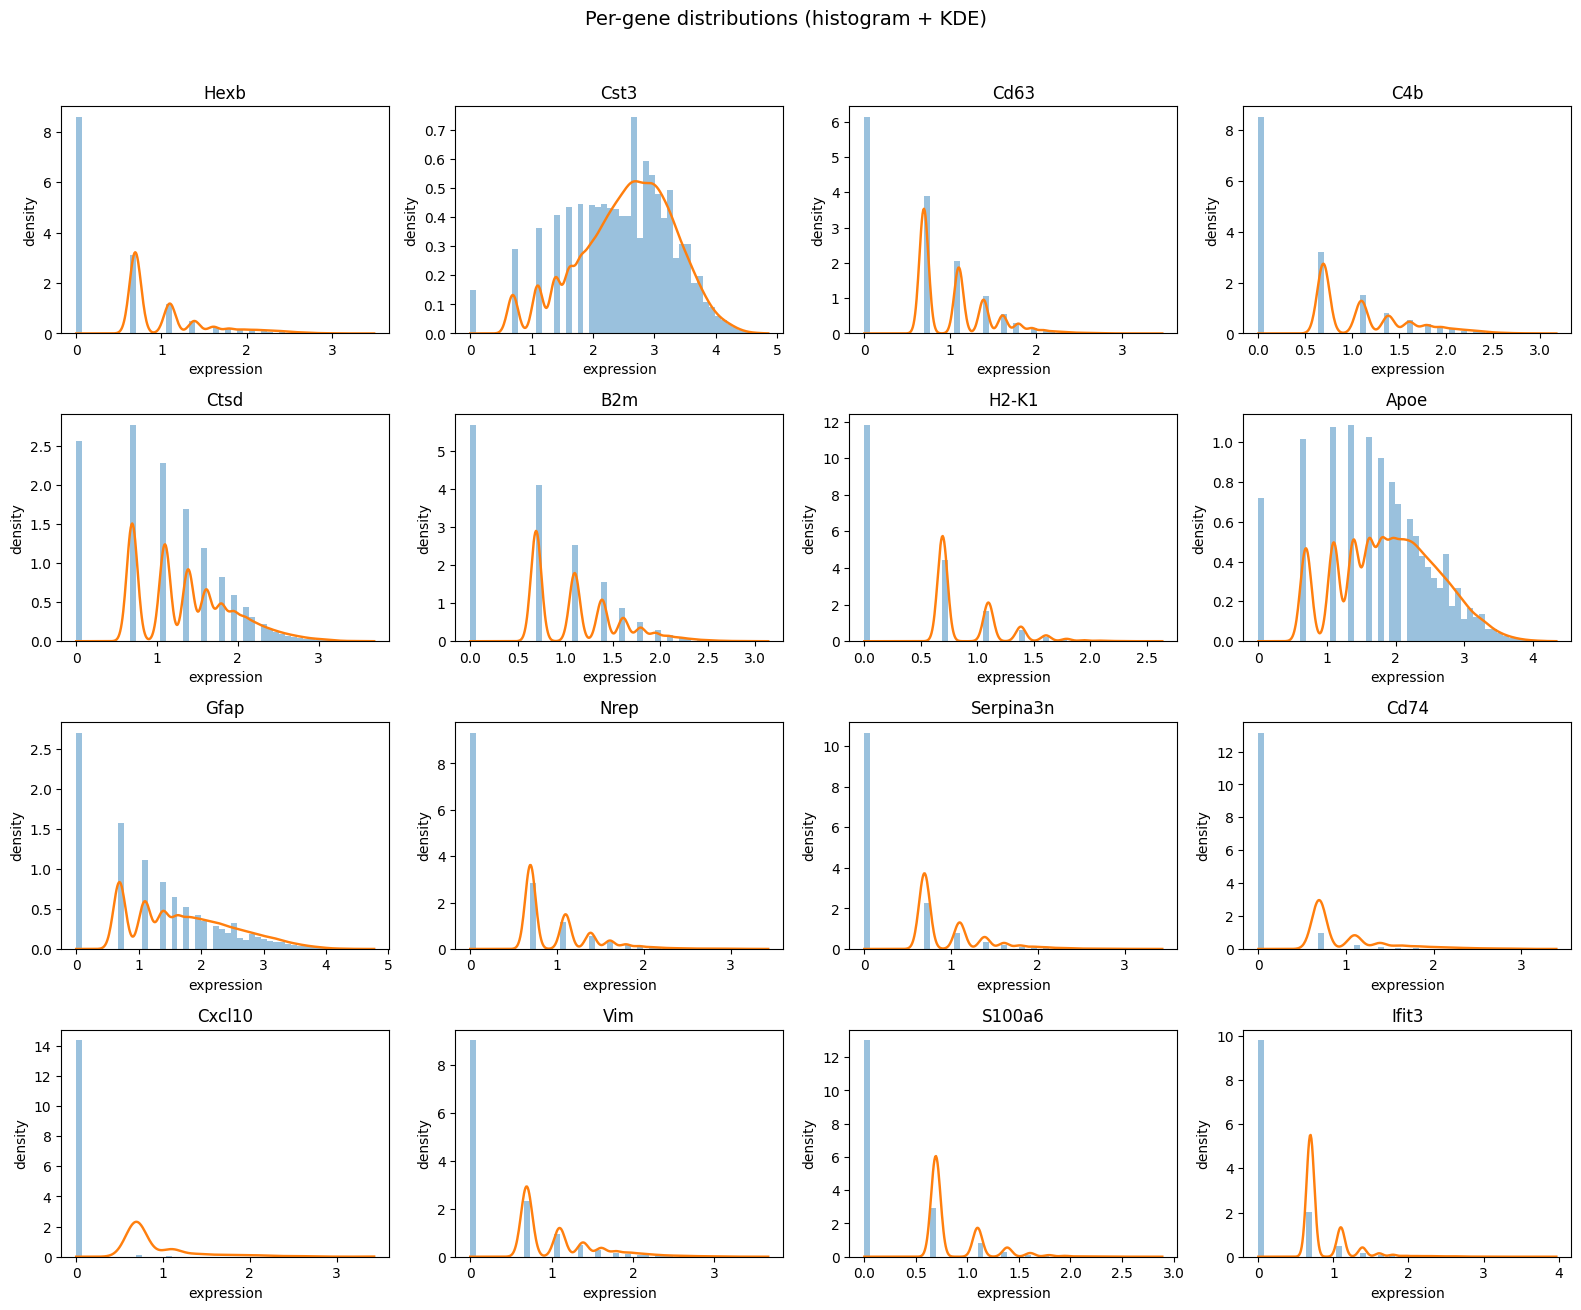